# IPC

In [2]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from src.datasources import ipc
from src.constants import *

In [4]:
df_ipc = ipc.load_raw_ipc()

In [6]:
df_ipc.dtypes

adm0_name           object
adm0_pcod2          object
adm0_pcod3          object
adm0_5_name         object
adm0_5_pcod2       float64
                    ...   
rCSI_Phase2        float64
rCSI_Phase3        float64
rCSI_finalphase    float64
notes               object
usethisperiod       object
Length: 61, dtype: object

In [7]:
df_ipc

,adm0_name,adm0_pcod2,adm0_pcod3,adm0_5_name,adm0_5_pcod2,adm1_name,adm1_pcod2,adm1_5_name,adm1_5_pcod2,adm2_name,...,LhHCSCat_StressStrategies,LhHCSCat_CrisisStategies,LhHCSCat_EmergencyStrategies,LhHCSCat_finalphase,rCSI_Phase1,rCSI_Phase2,rCSI_Phase3,rCSI_finalphase,notes,usethisperiod
0,Burkina Faso,BF,BFA,NaN,NaN,Centre,BF13,NaN,NaN,Kadiogo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
1,Burkina Faso,BF,BFA,NaN,NaN,Plateau Central,BF55,NaN,NaN,Ganzourgou,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
2,Burkina Faso,BF,BFA,NaN,NaN,Plateau Central,BF55,NaN,NaN,Oubritenga,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
3,Burkina Faso,BF,BFA,NaN,NaN,Plateau Central,BF55,NaN,NaN,Kourweogo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
4,Burkina Faso,BF,BFA,NaN,NaN,Centre-Sud,BF51,NaN,NaN,Bazega,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33305,Central African Republic,CF,CAF,NaN,NaN,Sangha-Mbaere,CF23,NaN,NaN,Bambio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
33306,Central African Republic,CF,CAF,NaN,NaN,Sangha-Mbaere,CF23,NaN,NaN,Bayanga,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
33307,Central African Republic,CF,CAF,NaN,NaN,Sangha-Mbaere,CF23,NaN,NaN,Nola,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
33308,Central African Republic,CF,CAF,NaN,NaN,Vakaga,CF53,NaN,NaN,Birao,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y


In [16]:
df_ipc.columns

Index(['adm0_name', 'adm0_pcod2', 'adm0_pcod3', 'adm0_5_name', 'adm0_5_pcod2',
       'adm1_name', 'adm1_pcod2', 'adm1_5_name', 'adm1_5_pcod2', 'adm2_name',
       'adm2_pcod2', 'adm2_5_name', 'adm2_5_pcod2', 'adm3_name', 'adm3_pcod2',
       'exercise_code', 'exercise_label', 'exercise_year', 'chtype',
       'reference_code', 'reference_label', 'reference_year', 'population',
       'phase_class', 'phase1', 'phase2', 'phase3', 'phase4', 'phase5',
       'phase35', 'foodconsumption_phase', 'livelihoods_phase',
       'nutrition_phase', 'mortality_phase', 'FCG_Poor', 'FCG_Borderline',
       'FCG_Acceptable', 'FCG_finalphase', 'HDDS_Phase1', 'HDDS_Phase2',
       'HDDS_Phase3', 'HDDS_Phase4', 'HDDS_Phase5', 'HDDS_finalphase',
       'HHS_Phase1', 'HHS_Phase2', 'HHS_Phase3', 'HHS_Phase4', 'HHS_Phase5',
       'HHS_finalphase', 'LhHCSCat_NoStrategies', 'LhHCSCat_StressStrategies',
       'LhHCSCat_CrisisStategies', 'LhHCSCat_EmergencyStrategies',
       'LhHCSCat_finalphase', 'rCSI_Phase

In [41]:
dff_proj = df_ipc[
    (df_ipc["adm1_pcod2"].isin(AOI_ADM1_PCODES))
    & (df_ipc["chtype"] == "projected")
    & (df_ipc["exercise_code"] == 1)
    & (df_ipc["reference_code"] == 3)
]

In [42]:
dff_current = df_ipc[
    (df_ipc["adm1_pcod2"].isin(AOI_ADM1_PCODES))
    & (df_ipc["chtype"] == "current")
    & (df_ipc["exercise_code"] == 1)
]

In [26]:
dff["exercise_label"].unique()

array(['Sep-Dec'], dtype=object)

In [27]:
dff["reference_code"].value_counts()

reference_code
3    158
Name: count, dtype: int64

In [28]:
dff["reference_label"].value_counts()

reference_label
Jun-Aug    158
Name: count, dtype: int64

In [29]:
dff["exercise_year"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [53]:
df_ipc_yearly_proj = (
    dff_proj.groupby("exercise_year")[["population", "phase35"]]
    .sum()
    .reset_index()
)
df_ipc_yearly_proj["frac35"] = (
    df_ipc_yearly_proj["phase35"] / df_ipc_yearly_proj["population"]
)

In [51]:
df_ipc_yearly_current = (
    dff_current.groupby("exercise_year")[["population", "phase35"]]
    .sum()
    .reset_index()
)
df_ipc_yearly_current["frac35"] = (
    df_ipc_yearly_current["phase35"] / df_ipc_yearly_current["population"]
)

In [57]:
df_ipc_yearly = df_ipc_yearly_current.merge(
    df_ipc_yearly_proj, on="exercise_year", suffixes=("_curr", "_proj")
)

In [58]:
df_ipc_yearly

,exercise_year,population_curr,phase35_curr,frac35_curr,population_proj,phase35_proj,frac35_proj
0,2015,6289180.0,74039.0,0.011772,6289180.0,344917.0,0.054843
1,2016,6470709.0,51941.0,0.008027,6470709.0,128927.0,0.019925
2,2017,6656745.0,117363.0,0.017631,6656745.0,471647.0,0.070852
3,2018,6847295.0,167480.0,0.024459,6847295.0,469788.0,0.068609
4,2019,7042433.0,749688.0,0.106453,7042433.0,1043627.0,0.148191
5,2020,7242022.0,1247598.0,0.172272,7242022.0,1628143.0,0.224819
6,2021,7033812.0,1106317.0,0.157286,7033812.0,1718024.0,0.244252
7,2022,6977556.0,1468652.0,0.210482,6977556.0,1936938.0,0.277595
8,2023,7290580.0,1425767.0,0.195563,7290581.0,1887306.0,0.258869


<Axes: xlabel='exercise_year'>

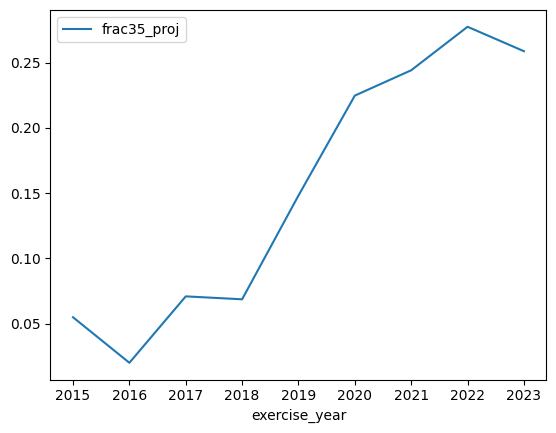

In [59]:
df_ipc_yearly.plot(x="exercise_year", y="frac35_proj")

<Axes: xlabel='exercise_year'>

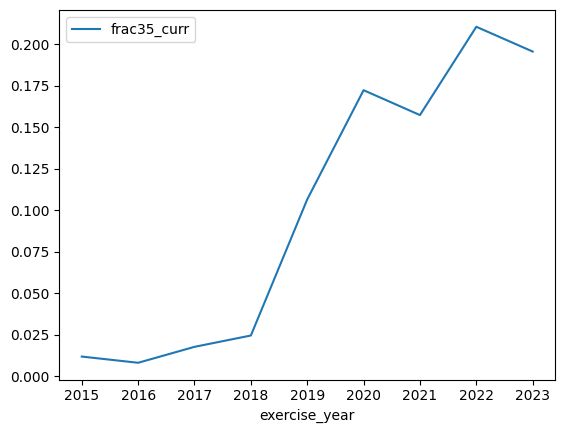

In [60]:
df_ipc_yearly.plot(x="exercise_year", y="frac35_curr")